# EDA

- Joaquin Bertaux
- Ignacio Borreani
- Franco Rodriguez
- Santiago Silvera

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## Basic information

In [2]:
col_names = ['temperatura', 'humedad', 'luz', 'humedad_suelo', 'label']
col_names_ts = ['timestamp'] + col_names

archivos = {
    'datos1.csv': dict(header=None, names=col_names_ts),
    'datos2.csv': dict(header=None, names=col_names),
    'datos3.csv': dict(header=0,    names=col_names),
    'datos4.csv': dict(header=None, names=col_names),
    'datos5.csv': dict(header=None, names=col_names),
}

partes = []
for nombre, kwargs in archivos.items():
    d = pd.read_csv(nombre, **kwargs)
    d['origen'] = nombre
    partes.append(d)

# Se hace drop de la columna de humedad, por problemas que se tuvieron con el sensor
# Para no poner datos nulos en el mismo, y como se tiene humedad de la tierra
# Se elije por ahora dejar de lado estos datos.
df = pd.concat(partes, ignore_index=True)
df = df.drop(columns=['humedad', 'timestamp'], errors='ignore')

# Para los demas datos, se usa la temperatura en grados centigrados
# Y el valor raw en mv para humedad de suelo y luminosidad.

print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())
print("\nDistribución de condiciones:")
print(df['label'].value_counts())
print("\nRegistros por archivo:")
print(df['origen'].value_counts())

Dataset Shape: (924, 5)

Data Types:
temperatura      float64
luz                int64
humedad_suelo      int64
label                str
origen               str
dtype: object

Basic Statistics:
       temperatura          luz  humedad_suelo
count   924.000000   924.000000     924.000000
mean     17.256872  3152.689394    1914.329004
std       6.567834   670.419259     531.521323
min       6.650000  1643.000000     511.000000
25%      12.760000  2771.000000    1756.750000
50%      13.270000  3275.500000    2116.500000
75%      24.300000  3754.250000    2320.000000
max      25.300000  4091.000000    2627.000000

Distribución de condiciones:
label
Estable    403
Ideal      403
Decaida    118
Name: count, dtype: int64

Registros por archivo:
origen
datos4.csv    211
datos2.csv    205
datos5.csv    198
datos3.csv    192
datos1.csv    118
Name: count, dtype: int64


In [3]:
print("\nMissing Values:")
print(df.isnull().sum())
print("\nNull Values Count:", df.isnull().sum().sum())


Missing Values:
temperatura      0
luz              0
humedad_suelo    0
label            0
origen           0
dtype: int64

Null Values Count: 0


## Correlation Matrix

Encoding de condiciones: {'Decaida': 0, 'Estable': 1, 'Ideal': 2}


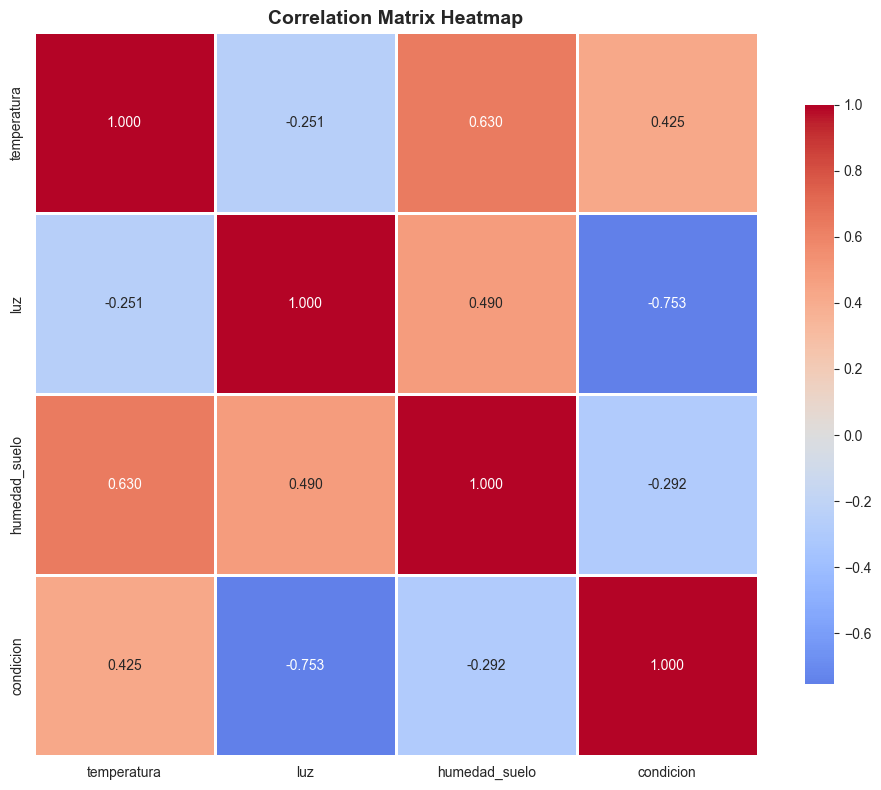

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

corr_df_plot = df[numeric_cols].copy()
if 'label' in df.columns:
    # El encoding asigna un entero a cada condición según el orden en que aparecen en el dataset:
    # Decaida=0, Estable=1, Ideal=2 (de peor a mejor estado de la planta)
    label_map = {v: i for i, v in enumerate(df['label'].unique())}
    corr_df_plot['condicion'] = df['label'].map(label_map)
    print("Encoding de condiciones:", label_map)

correlation_matrix = corr_df_plot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.3f', cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
print("Correlation Matrix Analysis:\n")
print(correlation_matrix)
print("\n" + "="*60)
print("Correlación por pares (excluyendo auto-correlación):")
print("="*60)

# Extraer correlaciones significativas
correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        col_i = correlation_matrix.columns[i]
        col_j = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]
        correlations.append({
            'Variable 1': col_i,
            'Variable 2': col_j,
            'Correlación': corr_value,
            'Fuerza': 'Muy Fuerte' if abs(corr_value) > 0.8 else 'Fuerte' if abs(corr_value) > 0.6 else 'Moderada' if abs(corr_value) > 0.4 else 'Nula'
        })

corr_df = pd.DataFrame(correlations).sort_values('Correlación', key=abs, ascending=False)
print(corr_df.to_string(index=False))

print("\n" + "="*60)
print("Interpretación:")
print("="*60)
strong_corr = corr_df[abs(corr_df['Correlación']) > 0.6]
if len(strong_corr) == 0:
    print("✓ No hay correlaciones fuertes (>0.6) entre variables")
    print("✓ Las variables son relativamente independientes")
    print("✓ Esto sugiere que cada sensor captura información única del sistema")
else:
    print("Variables con correlación fuerte (>0.6):")
    for idx, row in strong_corr.iterrows():
        print(f"  - {row['Variable 1']} vs {row['Variable 2']}: {row['Correlación']:.3f}")

Correlation Matrix Analysis:

               temperatura       luz  humedad_suelo  condicion
temperatura       1.000000 -0.250511       0.630323   0.424608
luz              -0.250511  1.000000       0.490037  -0.752852
humedad_suelo     0.630323  0.490037       1.000000  -0.291715
condicion         0.424608 -0.752852      -0.291715   1.000000

Correlación por pares (excluyendo auto-correlación):
   Variable 1    Variable 2  Correlación   Fuerza
          luz     condicion    -0.752852   Fuerte
  temperatura humedad_suelo     0.630323   Fuerte
          luz humedad_suelo     0.490037 Moderada
  temperatura     condicion     0.424608 Moderada
humedad_suelo     condicion    -0.291715     Nula
  temperatura           luz    -0.250511     Nula

Interpretación:
Variables con correlación fuerte (>0.6):
  - luz vs condicion: -0.753
  - temperatura vs humedad_suelo: 0.630


## Detección de Patrones por Condición de la Planta

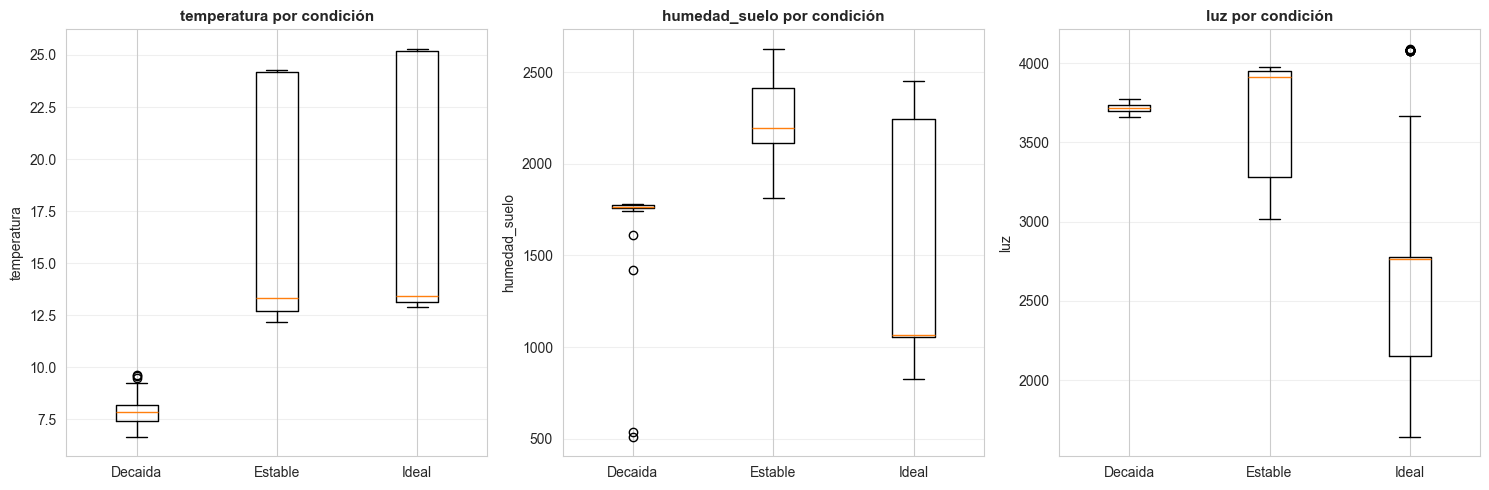


Estadísticas por condición:
        temperatura       humedad_suelo              luz        
               mean   std          mean     std     mean     std
label                                                           
Decaida        7.90  0.66       1740.68  164.16  3715.48   26.31
Estable       18.36  5.73       2259.28  182.74  3614.96  339.60
Ideal         18.89  6.04       1620.23  626.56  2525.63  463.75


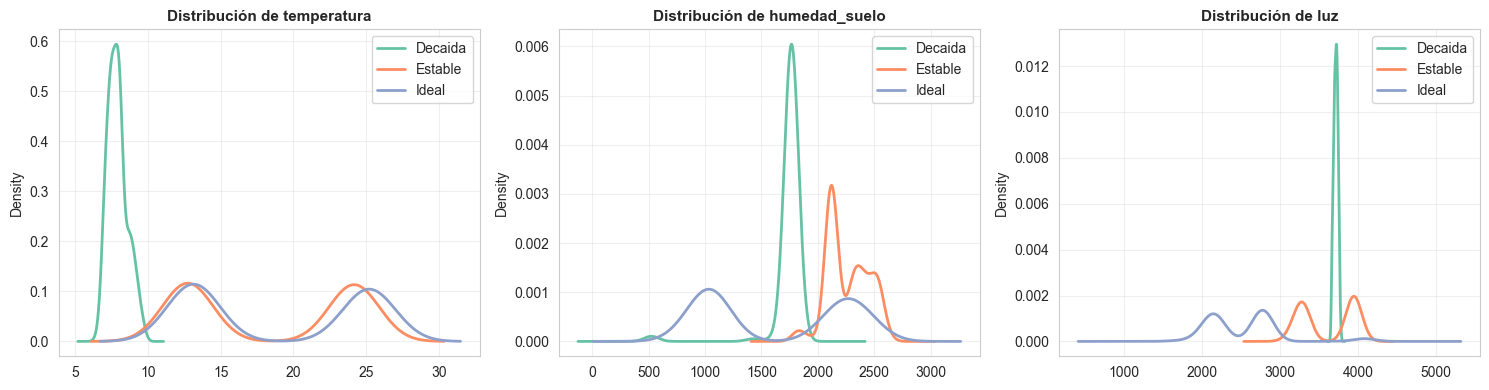

In [6]:
if 'label' in df.columns:
    sensor_cols = ['temperatura', 'humedad_suelo', 'luz']
    labels = df['label'].unique()

    # Boxplots por condición
    fig, axes = plt.subplots(1, len(sensor_cols), figsize=(15, 5))
    for idx, col in enumerate(sensor_cols):
        data_by_label = [df[df['label'] == lbl][col].dropna() for lbl in labels]
        axes[idx].boxplot(data_by_label, labels=labels)
        axes[idx].set_title(f'{col} por condición', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # Estadísticas por condición
    print("\nEstadísticas por condición:")
    print(df.groupby('label')[sensor_cols].agg(['mean', 'std']).round(2))

    # Distribuciones superpuestas
    fig, axes = plt.subplots(1, len(sensor_cols), figsize=(15, 4))
    colors = plt.cm.Set2.colors
    for idx, col in enumerate(sensor_cols):
        for i, lbl in enumerate(labels):
            subset = df[df['label'] == lbl][col].dropna()
            subset.plot(kind='density', ax=axes[idx], label=lbl, color=colors[i % len(colors)], linewidth=2)
        axes[idx].set_title(f'Distribución de {col}', fontsize=11, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró columna 'label' en el dataset.")

## PCA

PCA Analysis:
Explained Variance Ratio: [0.56327471 0.41367032 0.02305497]
Cumulative Explained Variance: [0.56327471 0.97694503 1.        ]


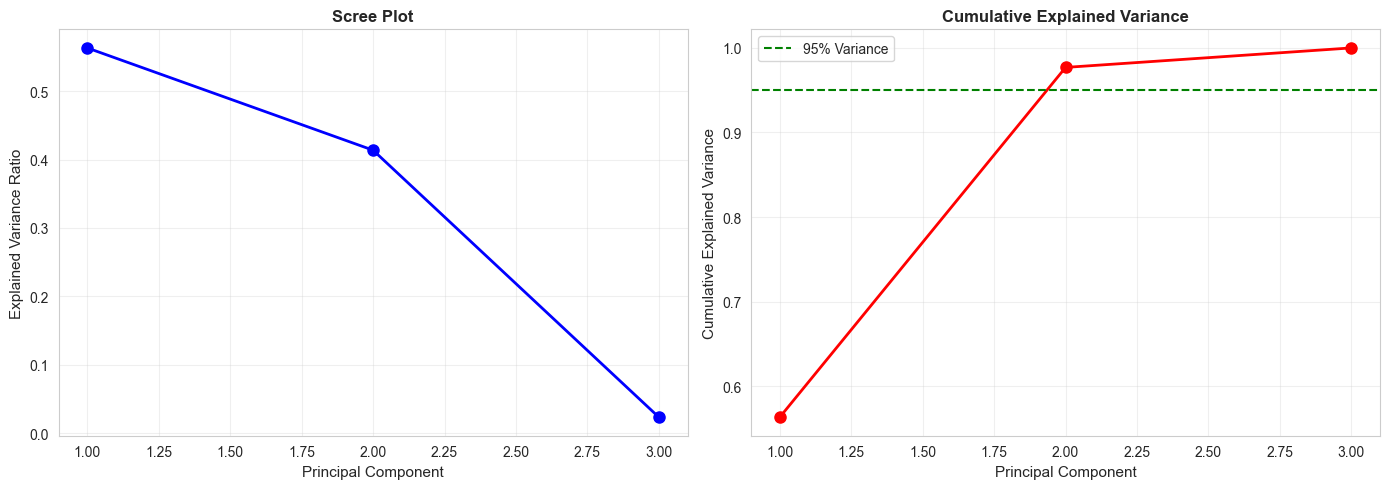

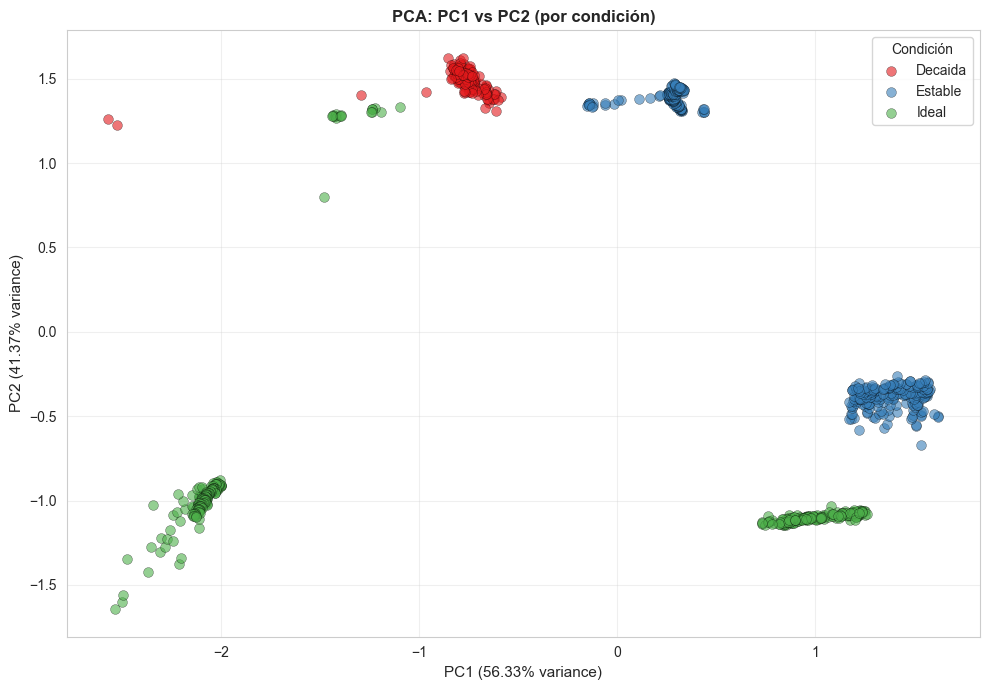

In [7]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
imputed_data = imputer.fit_transform(df[numeric_cols])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

pca = PCA()
pca_data = pca.fit_transform(scaled_data)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("PCA Analysis:")
print(f"Explained Variance Ratio: {explained_variance_ratio}")
print(f"Cumulative Explained Variance: {cumulative_variance}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=11)
axes[0].set_title('Scree Plot', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
axes[1].set_xlabel('Principal Component', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=11)
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# PC1 vs PC2 coloreado por condición
pca_df = pd.DataFrame(data=pca_data[:, :2], columns=['PC1', 'PC2'])

plt.figure(figsize=(10, 7))
if 'label' in df.columns:
    labels_unique = df['label'].unique()
    palette = plt.cm.Set1.colors
    for i, lbl in enumerate(labels_unique):
        mask = df['label'].values == lbl
        plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                    alpha=0.6, s=50, edgecolors='k', linewidth=0.3,
                    color=palette[i], label=lbl)
    plt.legend(title='Condición', fontsize=10)
    plt.title('PCA: PC1 vs PC2 (por condición)', fontsize=12, fontweight='bold')
else:
    plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
    plt.title('PCA: PC1 vs PC2', fontsize=12, fontweight='bold')

plt.xlabel(f'PC1 ({explained_variance_ratio[0]:.2%} variance)', fontsize=11)
plt.ylabel(f'PC2 ({explained_variance_ratio[1]:.2%} variance)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

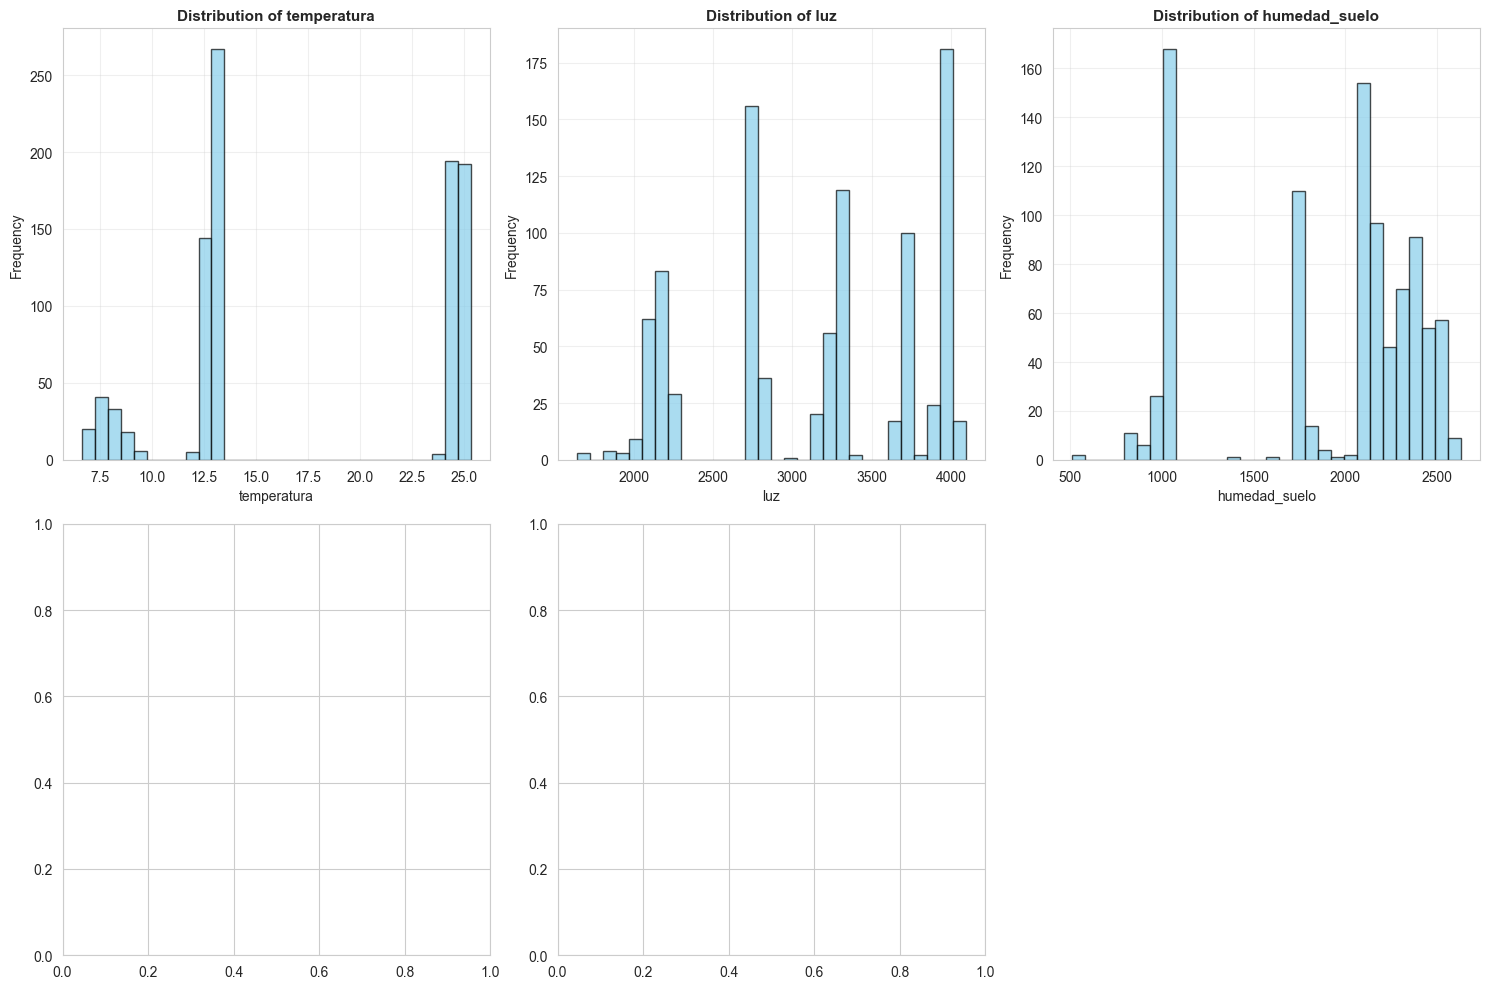

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

if len(numeric_cols) < 6:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

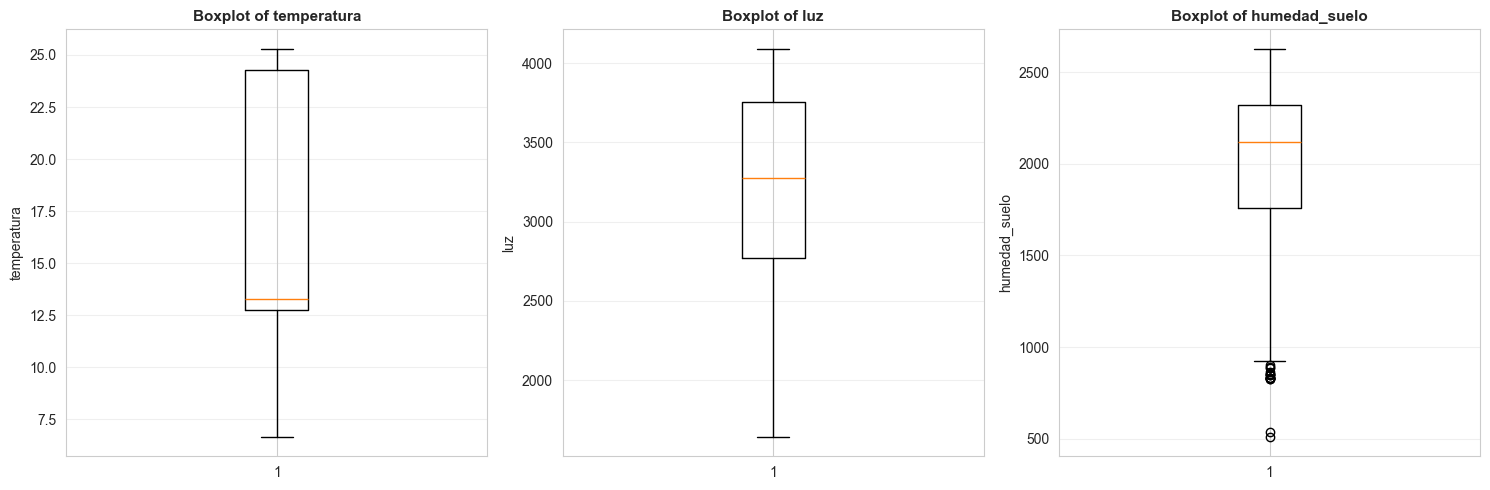

In [9]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 5))

if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df[col], vert=True)
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].set_title(f'Boxplot of {col}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [10]:
print("\nAnálisis de Outliers:")
print("="*60)
total_outliers = 0
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    total_outliers += len(outliers)
    
    if len(outliers) > 0:
        pct = (len(outliers) / len(df)) * 100
        print(f"\n{col}:  {len(outliers)} outliers ({pct:.1f}%)")
    else:
        print(f"\n{col}:  Sin outliers")

print("\n" + "="*60)
print(f"Total outliers detectados: {total_outliers} de {len(df)} registros ({(total_outliers/len(df)*100):.1f}%)")


Análisis de Outliers:

temperatura:  Sin outliers

luz:  Sin outliers

humedad_suelo:  17 outliers (1.8%)

Total outliers detectados: 17 de 924 registros (1.8%)


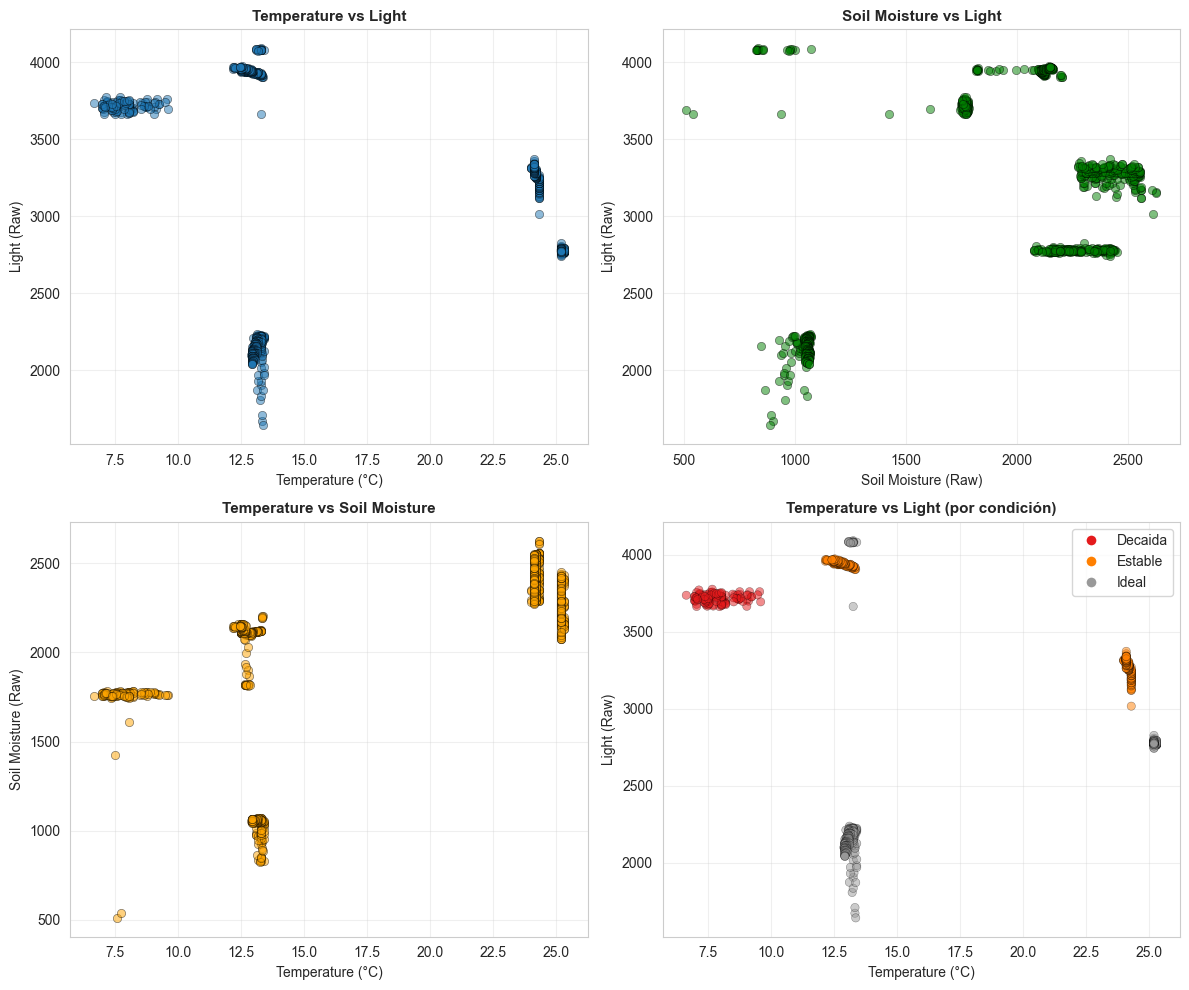

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(df['temperatura'], df['luz'], alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 0].set_xlabel('Temperature (°C)', fontsize=10)
axes[0, 0].set_ylabel('Light (Raw)', fontsize=10)
axes[0, 0].set_title('Temperature vs Light', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(df['humedad_suelo'], df['luz'], alpha=0.5, color='green', edgecolors='k', linewidth=0.5)
axes[0, 1].set_xlabel('Soil Moisture (Raw)', fontsize=10)
axes[0, 1].set_ylabel('Light (Raw)', fontsize=10)
axes[0, 1].set_title('Soil Moisture vs Light', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(df['temperatura'], df['humedad_suelo'], alpha=0.5, color='orange', edgecolors='k', linewidth=0.5)
axes[1, 0].set_xlabel('Temperature (°C)', fontsize=10)
axes[1, 0].set_ylabel('Soil Moisture (Raw)', fontsize=10)
axes[1, 0].set_title('Temperature vs Soil Moisture', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

if 'label' in df.columns:
    label_map = {v: i for i, v in enumerate(df['label'].unique())}
    colors_scatter = df['label'].map(label_map)
    sc = axes[1, 1].scatter(df['temperatura'], df['luz'], c=colors_scatter, cmap='Set1', alpha=0.5, edgecolors='k', linewidth=0.3)
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.Set1(v / max(label_map.values())), label=k, markersize=8) for k, v in label_map.items()]
    axes[1, 1].legend(handles=handles)
    axes[1, 1].set_title('Temperature vs Light (por condición)', fontsize=11, fontweight='bold')
else:
    axes[1, 1].scatter(df['temperatura'], df['luz'], alpha=0.5, color='purple', edgecolors='k', linewidth=0.5)
    axes[1, 1].set_title('Temperature vs Light', fontsize=11, fontweight='bold')

axes[1, 1].set_xlabel('Temperature (°C)', fontsize=10)
axes[1, 1].set_ylabel('Light (Raw)', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

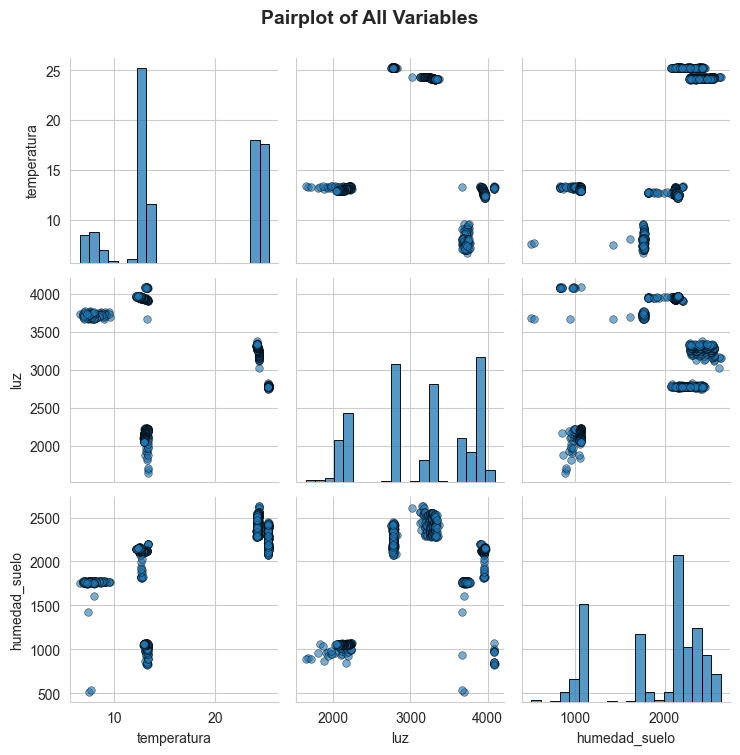

In [12]:
pairplot_data = df[numeric_cols].iloc[::max(1, len(df)//500)]
plt.figure(figsize=(12, 10))
pairplot = sns.pairplot(pd.DataFrame(pairplot_data, columns=numeric_cols), diag_kind='hist', plot_kws={'alpha': 0.6, 'edgecolor': 'k', 's': 30}, diag_kws={'bins': 20, 'edgecolor': 'black'})
pairplot.fig.suptitle('Pairplot of All Variables', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

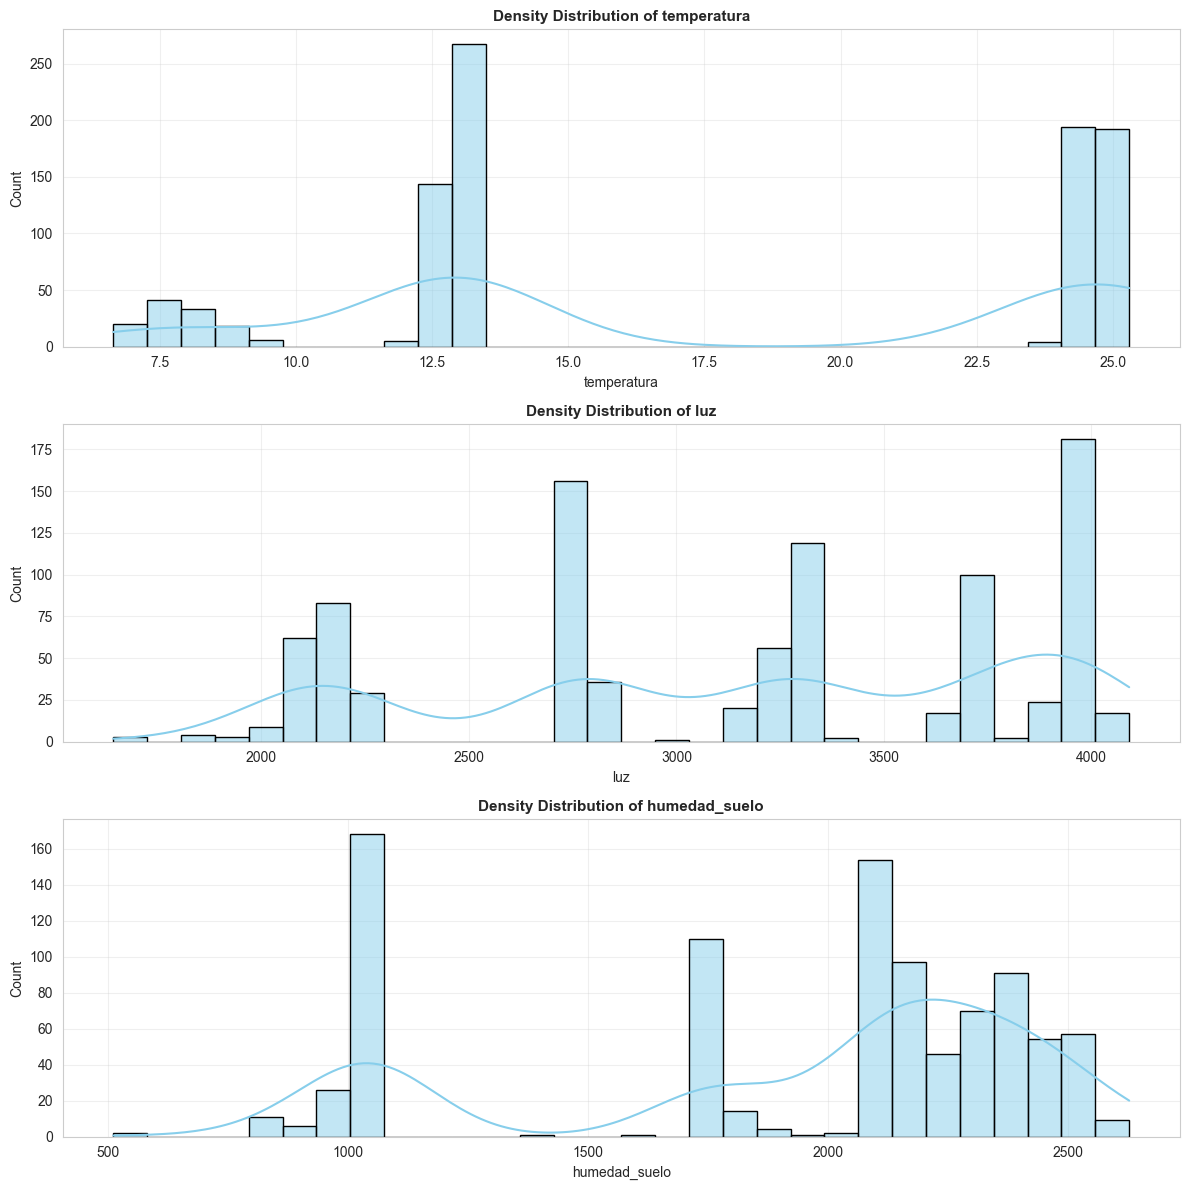

In [13]:
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(12, 4*len(numeric_cols)))

if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Density Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
from scipy.stats import skew, kurtosis

summary_stats = pd.DataFrame({
    'Column': numeric_cols,
    'Mean': [df[col].mean() for col in numeric_cols],
    'Std Dev': [df[col].std() for col in numeric_cols],
    'Min': [df[col].min() for col in numeric_cols],
    'Max': [df[col].max() for col in numeric_cols],
    'Q1': [df[col].quantile(0.25) for col in numeric_cols],
    'Median': [df[col].median() for col in numeric_cols],
    'Q3': [df[col].quantile(0.75) for col in numeric_cols],
    'Skewness': [skew(df[col].dropna()) for col in numeric_cols],
    'Kurtosis': [kurtosis(df[col].dropna()) for col in numeric_cols]
})

print("Statistical Summary:")
print(summary_stats.to_string(index=False))

Statistical Summary:
       Column        Mean    Std Dev     Min    Max      Q1  Median      Q3  Skewness  Kurtosis
  temperatura   17.256872   6.567834    6.65   25.3   12.76   13.27   24.30  0.117236 -1.657007
          luz 3152.689394 670.419259 1643.00 4091.0 2771.00 3275.50 3754.25 -0.300582 -1.213671
humedad_suelo 1914.329004 531.521323  511.00 2627.0 1756.75 2116.50 2320.00 -0.815452 -0.793672


## Conclusion


### Análisis del Sistema de Monitoreo de Planta

**Dataset combinado**: Se integraron 5 datasets recolectados en distintos dias, buscando conseguir una gran diversidad de condiciones para la planta. Esto resultó en 925 observaciones distribuidas en 3 clases: **Ideal**, **Estable** y **Decaida**. La variable de humedad ambiental fue excluida del análisis dado que el sensor en un momento dejó de funcionar, dando resultados de 0 en la misma. No hubo problemas con el tema de temperatura, gracias a que se tenía otro sensor que servía para lo mismo. El análisis se realizó sobre las tres variables restantes: temperatura, luz y humedad del suelo.

**Hallazgos principales**:

1. **Temperatura**: Es la variable más discriminante entre condiciones. La clase *Decaida* presenta valores notoriamente más bajos (en torno a 8–10°C) respecto a *Ideal* y *Estable* (20–25°C), lo que sugiere que la temperatura es un factor determinante en el estado de salud de la planta.

2. **Luz**: Es la variable con mayor correlación respecto a la condición de la planta (–0.753), lo que indica que a mayor intensidad lumínica, mejor es el estado de la planta. Muestra alta varianza dentro de cada clase por el ciclo día-noche capturado en las mediciones.

3. **Humedad del suelo**: Presenta una correlación fuerte y positiva con la temperatura (+0.630), lo que refleja que las condiciones de frío coinciden con tierra seca en el dataset *Decaida*. Se mantiene relativamente estable en condiciones *Ideal* y *Estable*.

4. **Correlaciones**: Las dos correlaciones más fuertes del dataset son luz vs condición (–0.753) y temperatura vs humedad del suelo (+0.630). La correlación entre temperatura y luz es débil (–0.251), lo que indica que ambos sensores capturan información independiente.

5. **PCA**: Los primeros dos componentes principales explican la mayor parte de la varianza. El gráfico PC1 vs PC2 coloreado por condición muestra que *Decaida* se separa claramente del resto, mientras que *Ideal* y *Estable* presentan cierta superposición, lo que sugiere que un clasificador podría distinguir la condición crítica con alta precisión.

6. **Outliers**: Solo se detectaron 17 outliers en humedad del suelo (1.8% del dataset), lo que indica que los datos recolectados son consistentes y confiables.

**Conclusión**: Las tres variables sensoriales capturan información relevante y diferenciable entre condiciones de la planta. La luz y la temperatura son los predictores más claros del estado de la planta. La separación observada en el espacio PCA indica que el dataset es adecuado para entrenar un modelo de clasificación supervisado en etapas posteriores del proyecto.